In [1]:
# Case Study
# Startup profit Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [170]:
# Step-1 Data collection

In [2]:
df=pd.read_csv('50_Startups.csv')

In [3]:
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [4]:
df.shape

(50, 5)

In [5]:
# Step-2 Data cleaning

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

R&D Spend          float64
Administration     float64
Marketing Spend    float64
State                  str
Profit             float64
dtype: object

In [9]:
# Step-3 EDA

In [10]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [11]:
cm=df.corr(numeric_only=True)

In [12]:
cm

,R&D Spend,Administration,Marketing Spend,Profit
R&D Spend,1.000000,0.241955,0.724248,0.972900
Administration,0.241955,1.000000,-0.032154,0.200717
Marketing Spend,0.724248,-0.032154,1.000000,0.747766
Profit,0.972900,0.200717,0.747766,1.000000


<Axes: >

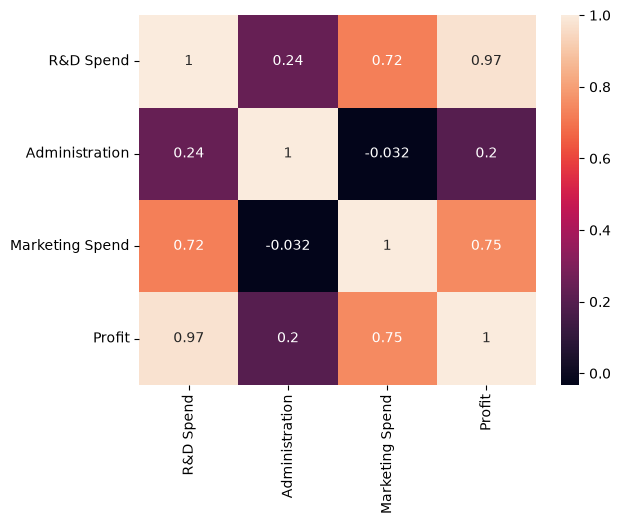

In [13]:
sns.heatmap(cm,annot=True)

<Axes: xlabel='State', ylabel='Profit'>

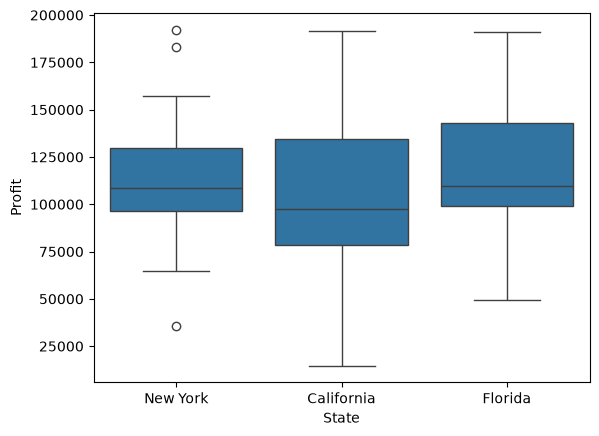

In [14]:
sns.boxplot(data=df,x='State',y='Profit')

In [15]:
# Step 4 ML Preprocessing

In [16]:
x=df.drop('Profit',axis=1)
y=df['Profit']

In [17]:
x

,R&D Spend,Administration,Marketing Spend,State
0,165349.20,136897.80,471784.10,New York
1,162597.70,151377.59,443898.53,California
2,153441.51,101145.55,407934.54,Florida
3,144372.41,118671.85,383199.62,New York
4,142107.34,91391.77,366168.42,Florida
5,131876.90,99814.71,362861.36,New York
6,134615.46,147198.87,127716.82,California
7,130298.13,145530.06,323876.68,Florida
8,120542.52,148718.95,311613.29,New York
9,123334.88,108679.17,304981.62,California


In [18]:
y

0     192261.83
1     191792.06
2     191050.39
3     182901.99
4     166187.94
5     156991.12
6     156122.51
7     155752.60
8     152211.77
9     149759.96
10    146121.95
11    144259.40
12    141585.52
13    134307.35
14    132602.65
15    129917.04
16    126992.93
17    125370.37
18    124266.90
19    122776.86
20    118474.03
21    111313.02
22    110352.25
23    108733.99
24    108552.04
25    107404.34
26    105733.54
27    105008.31
28    103282.38
29    101004.64
30     99937.59
31     97483.56
32     97427.84
33     96778.92
34     96712.80
35     96479.51
36     90708.19
37     89949.14
38     81229.06
39     81005.76
40     78239.91
41     77798.83
42     71498.49
43     69758.98
44     65200.33
45     64926.08
46     49490.75
47     42559.73
48     35673.41
49     14681.40
Name: Profit, dtype: float64

In [19]:
# Encoding
# Scalling
# CV

In [20]:
# Encoding

In [21]:
from sklearn.preprocessing import OneHotEncoder
oh=OneHotEncoder(sparse_output=False)
x[oh.get_feature_names_out()]=oh.fit_transform(x[['State']])

In [22]:
x.drop(columns=oh.feature_names_in_,inplace=True)

In [23]:
x

,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York
0,165349.20,136897.80,471784.10,0.0,0.0,1.0
1,162597.70,151377.59,443898.53,1.0,0.0,0.0
2,153441.51,101145.55,407934.54,0.0,1.0,0.0
3,144372.41,118671.85,383199.62,0.0,0.0,1.0
4,142107.34,91391.77,366168.42,0.0,1.0,0.0
5,131876.90,99814.71,362861.36,0.0,0.0,1.0
6,134615.46,147198.87,127716.82,1.0,0.0,0.0
7,130298.13,145530.06,323876.68,0.0,1.0,0.0
8,120542.52,148718.95,311613.29,0.0,0.0,1.0
9,123334.88,108679.17,304981.62,1.0,0.0,0.0


In [24]:
# Scalling

In [25]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x[['R&D Spend','Administration','Marketing Spend']]=sc.fit_transform(x[['R&D Spend','Administration','Marketing Spend']])

In [26]:
# cv

In [27]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=11)

In [28]:
X_train.shape

(40, 6)

In [29]:
X_test.shape

(10, 6)

In [30]:
# Step-5 Model Training

In [31]:
from sklearn.linear_model import LinearRegression
lg=LinearRegression()
lg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[37514.64,-1165.33, 3141.65, 1190.84, -71.54,-1119.3 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['R&D Spend','Administration','Marketing Spend','State_California', 'State_Florida','State_New York']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.109e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5


In [32]:
# Testing/ Evaluation/ Performance

In [33]:
lg.coef_

array([37514.6424575 , -1165.33448319,  3141.64657814,  1190.84320777,
         -71.54471732, -1119.29849045])

In [34]:
x.shape

(50, 6)

In [35]:
lg.intercept_

np.float64(110927.17649002453)

In [36]:
lg.score(X_train,y_train)*100

95.43493526038584

In [37]:
# Model Testing

In [38]:
y_pred=lg.predict(X_test)

In [39]:
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score

In [40]:
mean_absolute_error(y_test,y_pred)

9019.098123548694

In [41]:
root_mean_squared_error(y_test,y_pred)

11133.563073395979

In [42]:
r2_score(y_test,y_pred)*100

92.86946258325979

In [43]:
# Model Deployment

In [44]:
import pickle

In [45]:
with open('encoder','wb') as f:
    pickle.dump(oh,f)

In [46]:
with open('scaler','wb') as f:
    pickle.dump(sc,f)

In [47]:
with open('lrmodel','wb') as f:
    pickle.dump(lg,f)

In [48]:
# New Value Prediction

In [49]:
# R&D Spend    Administration    Marketing Spend       State
# 131876.90       99814.71            362861.36       New York

In [50]:
d1={
    'R&D Spend':[131876.90],
    'Administration':[99814.71],
    'Marketing Spend':[362861.36],
    'State':['New York']}

In [51]:
newdf=pd.DataFrame(d1)

In [52]:
newdf

,R&D Spend,Administration,Marketing Spend,State
0,131876.9,99814.71,362861.36,New York


In [53]:
newdf[oh.get_feature_names_out()]=oh.transform(newdf[['State']])

In [54]:
newdf.drop(columns=oh.feature_names_in_,inplace=True)

In [55]:
newdf

,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York
0,131876.9,99814.71,362861.36,0.0,0.0,1.0


In [56]:
# Scalling

In [57]:
newdf[['R&D Spend','Administration','Marketing Spend']]=sc.transform(newdf[['R&D Spend','Administration','Marketing Spend']])

In [58]:
newdf

,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York
0,1.2798,-0.776239,1.25421,0.0,0.0,1.0


In [59]:
# Prediction

In [60]:
lg.predict(newdf)

array([162663.9821136])

In [61]:
#Deployement